# DSAI4201 Project | OryxEye

## Animal Recognition & Cartoon Few-Shot Learning
## **EfficientNetV2S Fine Tuning + Prototypical Few-Shot**

## Imports

In [8]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import threading, time, tensorflow as tf
import json
import pickle

from google.colab import drive, files
from numpy.linalg import norm
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effnetv2_preprocess

## Setup

In [9]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
SAVE_PATH = '/content/drive/MyDrive/DSAI4201 Project/'
DATA_PATH = '/content/drive/MyDrive/DSAI4201 Project/animals'

## Load Fine Tuned Model - EfficientNetV2S

In [10]:
print(os.path.exists(f'{SAVE_PATH}EfficientNetV2S_finetuned_final.keras'))

True


In [11]:
model_v2s = load_model(f'{SAVE_PATH}EfficientNetV2S_finetuned_final.keras')

In [12]:
gen   = ImageDataGenerator(preprocessing_function=effnetv2_preprocess, validation_split=0.2)

val_ref = gen.flow_from_directory(DATA_PATH, target_size=(384,384), batch_size=16, subset='validation', shuffle=False)
class_names = list(val_ref.class_indices.keys())
print(f'{len(class_names)} classes loaded')

Found 1082 images belonging to 90 classes.
90 classes loaded


## Testing - Fine Tuned EfficientNetV2S

In [13]:
def predict(img_path, model, preprocess_fn, size, model_name):
    img  = keras_image.load_img(img_path, target_size=(size, size))
    arr  = np.expand_dims(preprocess_fn(keras_image.img_to_array(img)), axis=0)
    preds = model.predict(arr, verbose=0)[0]
    top3  = np.argsort(preds)[-3:][::-1]
    print(f'\nAnalyzing Uploaded Image:')
    plt.figure(figsize=(3, 3))
    plt.imshow(keras_image.load_img(img_path))
    plt.axis('off')
    plt.show()
    print('\t MODEL PREDICTIONS')
    print(f'This is a: {class_names[top3[0]]} ({preds[top3[0]]*100:.1f}%)')
    print(f'  Other possibilities:')
    for i in range(1, 3):
        print(f'    {i+1}. {class_names[top3[i]]:<20} {preds[top3[i]]*100:.1f}%')

In [14]:
uploaded = files.upload()

Saving OIP (1).jpg to OIP (1) (1).jpg
Saving OIP (2).jpg to OIP (2) (1).jpg
Saving OIP.jpg to OIP (3).jpg
Saving z.jpg to z (1).jpg
Saving zsgf.jpg to zsgf (1).jpg


Predicting Animals Using EfficientNetV2S Model

Analyzing Uploaded Image:


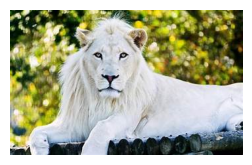

	 MODEL PREDICTIONS
This is a: lion (98.8%)
  Other possibilities:
    2. tiger                0.3%
    3. dog                  0.2%

Analyzing Uploaded Image:


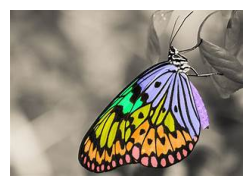

	 MODEL PREDICTIONS
This is a: butterfly (94.9%)
  Other possibilities:
    2. moth                 4.5%
    3. caterpillar          0.2%

Analyzing Uploaded Image:


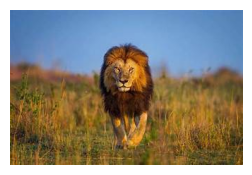

	 MODEL PREDICTIONS
This is a: lion (99.9%)
  Other possibilities:
    2. dog                  0.0%
    3. ox                   0.0%

Analyzing Uploaded Image:


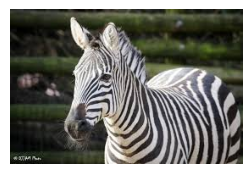

	 MODEL PREDICTIONS
This is a: zebra (99.0%)
  Other possibilities:
    2. okapi                0.8%
    3. caterpillar          0.0%

Analyzing Uploaded Image:


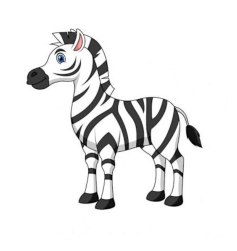

	 MODEL PREDICTIONS
This is a: okapi (52.5%)
  Other possibilities:
    2. zebra                46.0%
    3. hyena                0.2%


In [15]:
print("Predicting Animals Using EfficientNetV2S Model")
for fname in uploaded:
    predict(f'/content/{fname}', model_v2s, effnetv2_preprocess, 384, 'EfficientNetV2S')

## Few-Shot: Cartoon Domain Adaptation

*The fine tuned EfficientNetV2S backbone is used as a frozen feature extractor. Prototypes are built from both real (10 shots) and cartoon (10-20 shots) images. Prediction uses hybrid cosine similarity — 70% cartoon + 30% real.*

In [16]:
full_model = load_model(f'{SAVE_PATH}EfficientNetV2S_finetuned_final.keras')

# Build backbone using the EfficientNetV2S base inside the sequential model
base = full_model.layers[0]  # EfficientNetV2S base
gap  = full_model.layers[1]  # GlobalAveragePooling2D

inp = tf.keras.Input(shape=(384, 384, 3))
x   = base(inp, training=False)
x   = gap(x)

backbone = Model(inputs=inp, outputs=x)
backbone.trainable = False

print('Backbone ready — output shape:', backbone.output_shape)

Backbone ready — output shape: (None, 1280)


In [17]:
def extract_features(img_path):
    img = keras_image.load_img(img_path, target_size=(384, 384))
    arr = keras_image.img_to_array(img)
    arr = effnetv2_preprocess(arr)
    arr = np.expand_dims(arr, axis=0)
    features = backbone.predict(arr, verbose=0)
    return features[0]

In [18]:
def build_prototype(class_name, n_shots=10):
    class_dir = os.path.join(DATA_PATH, class_name)
    imgs = os.listdir(class_dir)[:n_shots]

    features = []
    for img_name in imgs:
        img_path = os.path.join(class_dir, img_name)
        features.append(extract_features(img_path))

    prototype = np.mean(features, axis=0)
    return prototype

In [19]:
prototypes = {}
for class_name in class_names:
    prototypes[class_name] = build_prototype(class_name, n_shots=10)
print(f'\nDone! {len(prototypes)} prototypes built for all 90 classes!')


Done! 90 prototypes built for all 90 classes!


In [20]:
cartoon_prototypes = {}
FEW_SHOT_PATH = f'{SAVE_PATH}few_shot_cartoon/'

classes = sorted(os.listdir(FEW_SHOT_PATH))

print(f'Building cartoon prototypes for {len(classes)} classes:\n')
for class_name in classes:
    class_dir = os.path.join(FEW_SHOT_PATH, class_name)
    imgs = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]

    features = []
    for img_name in imgs:
        img_path = os.path.join(class_dir, img_name)
        features.append(extract_features(img_path))

    cartoon_prototypes[class_name] = np.mean(features, axis=0)
    print(f'\t{class_name}\t  -  \t{len(imgs)} images')

Building cartoon prototypes for 32 classes:

	bee	  -  	12 images


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


	cat	  -  	21 images
	dog	  -  	21 images
	dolphin	  -  	11 images
	elephant	  -  	15 images
	fly	  -  	15 images
	fox	  -  	15 images
	horse	  -  	16 images
	lion	  -  	19 images
	pelecaniformes	  -  	14 images
	penguin	  -  	10 images
	pig	  -  	15 images
	pigeon	  -  	15 images
	rabbit	  -  	16 images
	rat	  -  	20 images
	reindeer	  -  	10 images
	shark	  -  	12 images
	sheep	  -  	10 images
	snake	  -  	12 images
	sparrow	  -  	6 images
	squid	  -  	11 images
	squirrel	  -  	12 images
	starfish	  -  	12 images
	swan	  -  	13 images
	tiger	  -  	9 images
	turkey	  -  	15 images
	turtle	  -  	13 images
	whale	  -  	17 images
	wolf	  -  	17 images
	wombat	  -  	18 images
	woodpecker	  -  	12 images
	zebra	  -  	20 images


In [21]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

In [22]:
def predict_cartoon(img_path, top_k=3):
    query = extract_features(img_path)

    scores = {}
    for class_name, proto in cartoon_prototypes.items():
        cartoon_score = cosine_similarity(query, proto)
        if class_name in prototypes:
            real_score = cosine_similarity(query, prototypes[class_name])
            scores[class_name] = 0.7 * cartoon_score + 0.3 * real_score
        else:
            scores[class_name] = cartoon_score

    top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    print(f'\nAnalyzing Uploaded Image:')

    plt.figure(figsize=(3,3))
    plt.imshow(keras_image.load_img(img_path))
    plt.axis('off')
    plt.show()
    print('\t MODEL PREDICTIONS')
    print('This is a:', top[0][0], f'({top[0][1]*100:.1f}%)')
    print('\nOther possibilities:')
    for i, (name, score) in enumerate(top[1:], 2):
        print(f'  {i}. {name:<20} {score*100:.1f}%')

    return top

In [23]:
uploaded = files.upload()

Saving OIP (1).jpg to OIP (1) (2).jpg
Saving OIP (2).jpg to OIP (2) (2).jpg
Saving OIP (4).jpg to OIP (4).jpg
Saving OIP.jpg to OIP (5).jpg


Predicting Using EfficientNetV2S Model, After Few Shot

Analyzing Uploaded Image:


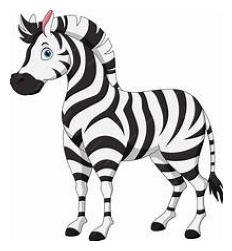

	 MODEL PREDICTIONS
This is a: zebra (72.0%)

Other possibilities:
  2. tiger                39.1%
  3. horse                28.5%

Analyzing Uploaded Image:


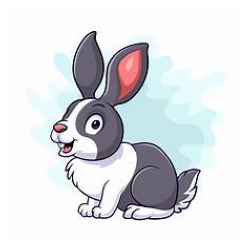

	 MODEL PREDICTIONS
This is a: rabbit (82.9%)

Other possibilities:
  2. rat                  38.1%
  3. pig                  34.0%

Analyzing Uploaded Image:


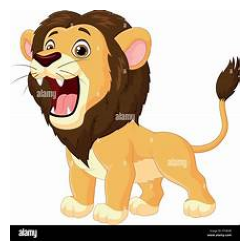

	 MODEL PREDICTIONS
This is a: lion (47.5%)

Other possibilities:
  2. dog                  42.4%
  3. rat                  38.9%

Analyzing Uploaded Image:


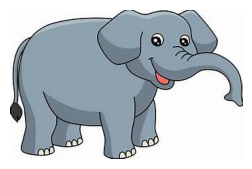

	 MODEL PREDICTIONS
This is a: elephant (54.1%)

Other possibilities:
  2. dog                  41.0%
  3. horse                39.5%


In [24]:
print("Predicting Using EfficientNetV2S Model, After Few Shot")
for fname in uploaded:
    predict_cartoon(f'/content/{fname}')

## Save Models

In [ ]:
# Save animal class labels for the app
animal_labels = {str(i): name for i, name in enumerate(class_names)}
with open(f'{SAVE_PATH}animal_labels.json', 'w') as f:
    json.dump(animal_labels, f)

print(f'Saved animal_labels.json with {len(animal_labels)} classes')

Saved animal_labels.json with 90 classes


In [27]:
# save models
backbone.save(f'{SAVE_PATH}OryxEye_backbone.keras')
pickle.dump(prototypes, open(f'{SAVE_PATH}OryxEye_base_prototypes.pkl', 'wb'))
pickle.dump(cartoon_prototypes, open(f'{SAVE_PATH}OryxEye_cartoon_prototypes.pkl', 'wb'))

print('All saved!')

All saved!


In [28]:
# load models
backbone = load_model(f'{SAVE_PATH}OryxEye_backbone.keras')

with open(f'{SAVE_PATH}OryxEye_base_prototypes.pkl', 'rb') as f:
    prototypes = pickle.load(f)

with open(f'{SAVE_PATH}OryxEye_cartoon_prototypes.pkl', 'rb') as f:
    cartoon_prototypes = pickle.load(f)

print('All loaded!')

All loaded!
